# Finite Difference

Finite difference methods approximate derivatives using discrete function values sampled at neighboring points separated by a finite interval, rather than evaluating them analytically. As the foundation of many numerical algorithms in computational physics, these methods are widely used to solve ordinary and partial differential equations, as well as to estimate velocities, accelerations, forces, and fluxes from experimental measurements or numerical simulations. Demonstrating these concepts, this notebook applies finite-difference approximations to compute the acceleration and jerk from a time-dependent velocity profile.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Velocity Profile

Consider a smooth velocity profile $v(t)$, which represents the motion of a particle as a function of time. The following code generates the velocity data used throughout this notebook.


In [3]:
v = lambda t: 100 / (1 + np.exp(-0.05*(t-100))) - 100 / (1 + np.exp(-0.02*(t-950)))

In [4]:
t = np.linspace(0, 1200, 2400)
dt = t[1] - t[0]
v_vals = v(t)

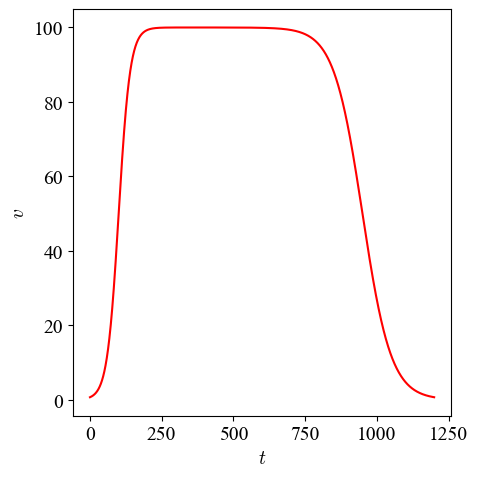

In [5]:
plt.figure(figsize=(5, 5))
plt.plot(t, v_vals, color="r")
plt.xlabel(r"$t$")
plt.ylabel(r"$v$")
plt.tight_layout()
plt.show()

## First Derivative

The acceleration is defined as the first derivative of the velocity,

$$
a(t)=\frac{dv}{dt}.
$$

For discrete samples, the derivative can be approximated using several finite-difference schemes.

## Forward Difference

The forward difference approximation uses the function value at the current point and the next neighboring point,

$$
a_i\approx\frac{v_{i+1}-v_i}{\Delta t},
$$

where $\Delta t$ denotes the step size. This approximation is first-order accurate with a truncation error of $O(\Delta t)$.

In [6]:
a_forward = np.zeros_like(v_vals)
a_forward[:-1] = (v_vals[1:] - v_vals[:-1]) / dt
a_forward[-1] = a_forward[-2]

## Backward Difference

The backward difference approximation uses the current point and the previous neighboring point,

$$
a_i\approx\frac{v_i-v_{i-1}}{\Delta t},
$$

which is also first-order accurate, $\mathcal{O}(\Delta t)$.

In [7]:
a_backward = np.zeros_like(v_vals)
a_backward[1:] = (v_vals[1:] - v_vals[:-1]) / dt
a_backward[0] = a_backward[1]

## Central Difference

The central difference approximation evaluates the derivative using points on both sides of the target location,

$$
a_i\approx\frac{v_{i+1}-v_{i-1}}{2\Delta t},
$$

providing a second-order accurate approximation $\mathcal{O}(\Delta t^2)$, which generally produces smaller truncation errors than the forward and backward difference methods.

In [8]:
a_central = np.zeros_like(v_vals)
a_central[1:-1] = (v_vals[2:] - v_vals[:-2]) / (2*dt)
a_central[0] = a_forward[0]
a_central[-1] = a_backward[-1]

## Comparison of Finite-Difference Schemes

The computed accelerations are compared to illustrate the differences between the three finite-difference approximations. The central difference generally provides a more accurate estimate because it utilizes information from both neighboring points.

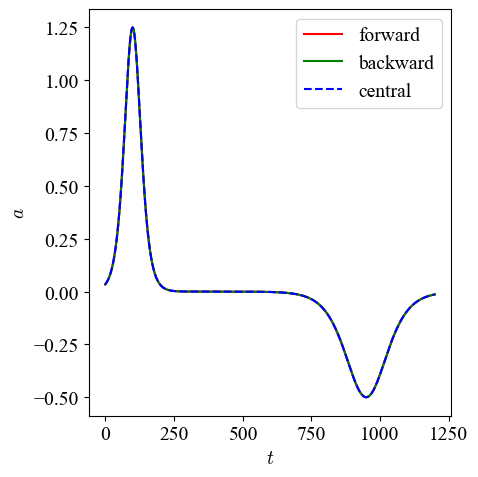

In [9]:
plt.figure(figsize=(5, 5))
plt.plot(t, a_forward, color="r", label="forward")
plt.plot(t, a_backward, '-', color="g", label="backward")
plt.plot(t, a_central, '--', color="b", label="central")
plt.xlabel(r"$t$")
plt.ylabel(r"$a$")
plt.legend()
plt.tight_layout()
plt.show()

## Second Derivative

The jerk is defined as the time derivative of the acceleration,

$$
j(t)=\frac{da}{dt}=\frac{d^2v}{dt^2}.
$$

Using the central finite-difference approximation, the second derivative is computed as

$$
j_i\approx\frac{v_{i+1}-2v_i+v_{i-1}}{\Delta t^2},
$$

which is second-order accurate. The following code evaluates the jerk from the sampled velocity data.

In [10]:
j = np.zeros_like(v_vals)
j[1:-1] = (v_vals[2:] - 2*v_vals[1:-1] + v_vals[:-2]) / (dt**2)
j[0] = j[1]
j[-1] = j[-2]

The resulting jerk profile highlights the rate of change of acceleration during the particle motion. Large positive or negative values indicate rapid variations in acceleration, corresponding to transient changes in the velocity profile.

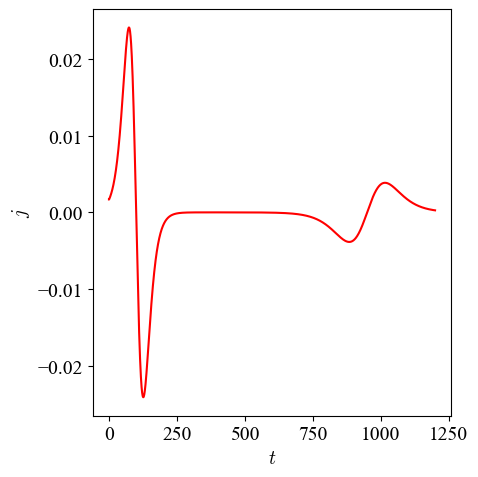

In [11]:
plt.figure(figsize=(5, 5))
plt.plot(t, j, color="r")
plt.xlabel(r"$t$")
plt.ylabel(r"$j$")
plt.tight_layout()
plt.show()

## Key Insights

* Finite difference methods approximate derivatives from discrete data samples.
* Forward and backward differences are first-order accurate, whereas the central difference is second-order accurate.
* Acceleration is obtained from the first derivative of the velocity, while jerk corresponds to the second derivative.
* Central finite differences generally provide more accurate derivative estimates for smooth data.